# 05 — Physically motivated features from the raw signal

Instead of isolated points, this notebook uses dynamics within temperature phases and an
Adaptive Linear Approximation (ALA). Ridge models compare 48 raw boundaries, phase dynamics,
ALA means and slopes, and both feature families together. Sensor A, channel 0, and the grouped
UGM splits remain unchanged.

## Software, physical assumptions, and parameters

`GAS`, `N_ALA_SEGMENTS`, and `RIDGE_ALPHAS` control the experiment. `physics_features.py`
extracts start, end, amplitude, initial slope, tau63, first-order response error, and a threshold
quality flag for all 24 temperature phases. ALA breakpoints are learned from the training median;
each segment contributes a mean and slope. Ridge regularization is selected on validation only.

tau63 equals a physical time constant only for an approximately first-order response. The error
and quality flag expose deviations. Scaling, ALA boundaries, and alpha selection never see test
or `test_extra`.

In [1]:
GAS = "hydrogen"
N_ALA_SEGMENTS = 50
RIDGE_ALPHAS = None

In [2]:
from pathlib import Path
from html import escape
import sys
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import HTML, display
from sklearn.linear_model import Ridge

HERE = Path.cwd()
if not (HERE / "dataset_pipeline.py").exists():
    HERE = HERE / "Evaluation Seminar" / "Day_02"
sys.path.insert(0, str(HERE.resolve()))

from dataset_pipeline import *
from physics_features import (
    extract_ala_features,
    extract_phase_features,
    learn_ala_breakpoints,
    reconstruct_ala,
    temperature_phases,
)

if GAS not in GAS_TARGETS:
    raise ValueError(f"Unknown gas: {GAS}")
if RIDGE_ALPHAS is None:
    RIDGE_ALPHAS = np.logspace(-4, 6, 21)
plt.style.use("seaborn-v0_8-whitegrid")
splits = prepare_splits("stored")

def show_table(rows, columns, digits=3):
    def formatted(value):
        if isinstance(value, (float, np.floating)):
            return f"{value:.{digits}f}"
        return str(value)
    header = "".join(f"<th>{escape(column)}</th>" for column in columns)
    body = "".join(
        "<tr>" + "".join(
            f"<td>{escape(formatted(row[column]))}</td>" for column in columns
        ) + "</tr>"
        for row in rows
    )
    display(HTML(f"<table><thead><tr>{header}</tr></thead><tbody>{body}</tbody></table>"))

## 1. Time constants and other phase features

Each high- and low-temperature phase produces start, end, amplitude, initial slope, time to
63.2% of the observed response, first-order response error, and a threshold-reached flag.
For an ideal first-order system, tau63 equals the time constant; here it is a robust direct
estimate rather than a forced nonlinear fit.

In [3]:
phase_features = {}
for split in SPLIT_NAMES:
    values, phase_names = extract_phase_features(splits[split]["X"])
    phase_features[split] = values

print("Temperatureeee phases:", len(temperature_phases()))
print("Phase features:", len(phase_names))
print("Training shape:", phase_features["train"].shape)

tau_columns = [i for i, name in enumerate(phase_names) if name.endswith("tau63_s")]
found_columns = [
    i for i, name in enumerate(phase_names)
    if name.endswith("tau_crossing_found")
]
tau_summary = []
for tau_col, found_col in zip(tau_columns, found_columns):
    tau_summary.append({
        "Phase": phase_names[tau_col].replace("__tau63_s", ""),
        "Median tau [s]": np.median(phase_features["train"][:, tau_col]),
        "Threshold reached [%]":
            100 * np.mean(phase_features["train"][:, found_col]),
    })
show_table(
    tau_summary,
    ["Phase", "Median tau [s]", "Threshold reached [%]"],
    digits=2,
)

Temperatureeee phases: 24
Phase features: 168
Training shape: (1090, 168)


Phase,Median tau [s],Threshold reached [%]
step00_high_t400,1.87,100.00
step00_low_t100,0.08,100.00
step01_high_t400,2.77,100.00
step01_low_t125,0.08,100.00
step02_high_t400,2.69,100.00
step02_low_t150,0.07,100.00
step03_high_t400,2.67,100.00
step03_low_t175,5.30,99.91
step04_high_t400,2.60,100.00
step04_low_t200,4.12,100.00


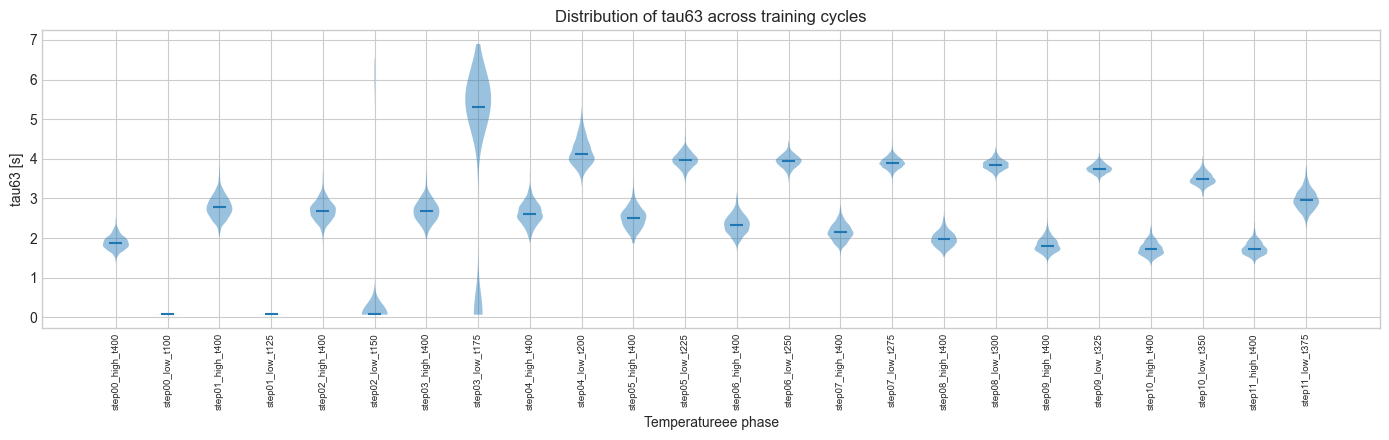

In [4]:
tau_values = phase_features["train"][:, tau_columns]
fig, ax = plt.subplots(figsize=(14, 4.5))
parts = ax.violinplot(tau_values, showmedians=True, showextrema=False)
for body in parts["bodies"]:
    body.set_alpha(0.45)
ax.set(
    xlabel="Temperatureee phase",
    ylabel="tau63 [s]",
    title="Distribution of tau63 across training cycles",
)
ax.set_xticks(
    np.arange(1, len(tau_columns) + 1),
    [name.replace("__tau63_s", "") for name in np.array(phase_names)[tau_columns]],
    rotation=90,
    fontsize=7,
)
plt.tight_layout()

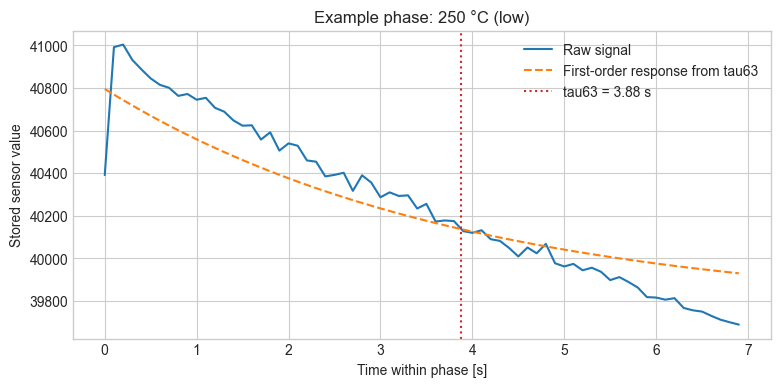

In [5]:
example_index = len(splits["train"]["X"]) // 2
cycle = splits["train"]["X"][example_index, 0].astype(float)
phase = temperature_phases()[13]  # 250 °C low
values = cycle[phase.start:phase.stop]
local_features, local_names = extract_phase_features(
    splits["train"]["X"][example_index:example_index + 1]
)
prefix = phase.label + "__"
lookup = {
    name.removeprefix(prefix): local_features[0, i]
    for i, name in enumerate(local_names) if name.startswith(prefix)
}
t = np.arange(len(values)) / SAMPLE_RATE_HZ
fitted = lookup["start"] + lookup["amplitude"] * (
    1 - np.exp(-t / max(lookup["tau63_s"], 1 / SAMPLE_RATE_HZ))
)

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(t, values, label="Raw signal")
ax.plot(t, fitted, "--", label="First-order response from tau63")
ax.axvline(lookup["tau63_s"], color="tab:red", linestyle=":",
           label=f"tau63 = {lookup['tau63_s']:.2f} s")
ax.set(xlabel="Time within phase [s]", ylabel="Stored sensor value",
       title=f"Example phase: {phase.temperature_c} °C ({phase.kind})")
ax.legend()
plt.show()

## 2. Adaptive Linear Approximation

ALA places breakpoints where reconstruction error is large. Breakpoints are learned only from
the median training signal and then frozen for every split. With 50 segments, one channel yields
100 features: one mean and one slope per segment.

In [6]:
train_reference = np.median(splits["train"]["X"][:, 0, :], axis=0)
ala_breakpoints = learn_ala_breakpoints(
    train_reference, n_segments=N_ALA_SEGMENTS
)
ala_reconstruction = reconstruct_ala(train_reference, ala_breakpoints)

ala_features = {}
for split in SPLIT_NAMES:
    values, ala_names = extract_ala_features(
        splits[split]["X"], ala_breakpoints
    )
    ala_features[split] = values

reconstruction_rmse = np.sqrt(
    np.mean((train_reference - ala_reconstruction) ** 2)
)
print("ALA breakpoints:", len(ala_breakpoints))
print("ALA features:", len(ala_names))
print(f"Median reconstruction RMSE: {reconstruction_rmse:.2f}")

ALA breakpoints: 51
ALA features: 100
Median reconstruction RMSE: 1359.52


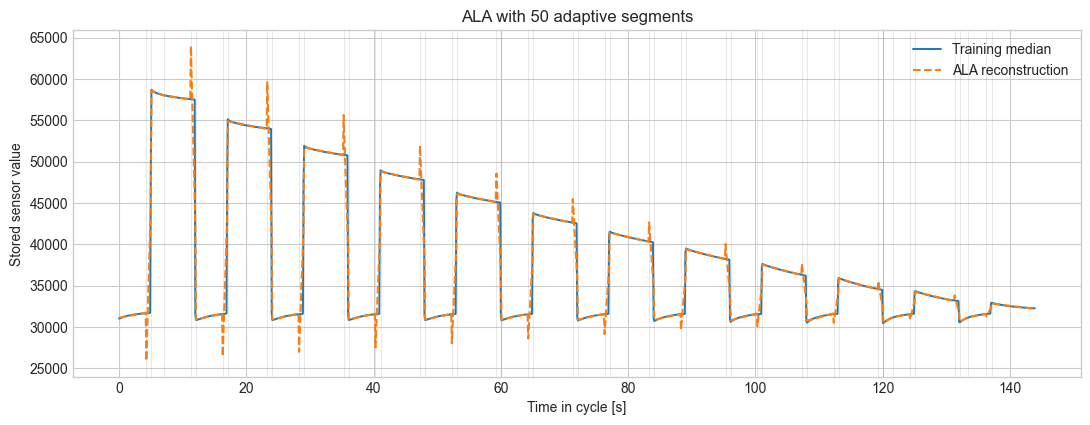

In [7]:
time_s = np.arange(CYCLE_SAMPLES) / SAMPLE_RATE_HZ
fig, ax = plt.subplots(figsize=(13, 4.5))
ax.plot(time_s, train_reference, label="Training median", linewidth=1.4)
ax.plot(time_s, ala_reconstruction, "--", label="ALA reconstruction")
for point in ala_breakpoints[1:-1]:
    ax.axvline(point / SAMPLE_RATE_HZ, color="grey", alpha=0.18, linewidth=0.7)
ax.set(xlabel="Time in cycle [s]", ylabel="Stored sensor value",
       title=f"ALA with {N_ALA_SEGMENTS} adaptive segments")
ax.legend()
plt.show()

## 3. Fair model comparison

Ridge is useful because many phase values, means, and slopes are correlated. Mean, standard
deviation, and Ridge strength are learned from training and validation only; neither test split
influences the model.

In [8]:
boundary_indices = [point.index for point in temperature_boundary_points()]
raw_boundary_features = {
    split: splits[split]["X"][:, 0, boundary_indices].astype(float)
    for split in SPLIT_NAMES
}
combined_features = {
    split: np.column_stack((phase_features[split], ala_features[split]))
    for split in SPLIT_NAMES
}
feature_sets = {
    "48 raw boundary points": raw_boundary_features,
    "Phase dynamics": phase_features,
    "ALA": ala_features,
    "Phase dynamics + ALA": combined_features,
}

def regression_metrics(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=float)
    residual = y_true - np.asarray(y_pred, dtype=float)
    mse = float(np.mean(residual ** 2))
    denominator = float(np.sum((y_true - y_true.mean()) ** 2))
    return {
        "R2": 1 - float(np.sum(residual ** 2)) / denominator,
        "MSE": mse,
        "RMSE": np.sqrt(mse),
        "MAE": float(np.mean(np.abs(residual))),
    }

def tune_ridge(feature_dict):
    mean = feature_dict["train"].mean(axis=0)
    scale = feature_dict["train"].std(axis=0)
    scale[scale < 1e-12] = 1.0

    def standardized(split):
        return (feature_dict[split] - mean) / scale

    y_train = splits["train"]["targets"][GAS].astype(float)
    y_val = splits["val"]["targets"][GAS].astype(float)
    trials = []
    for alpha in RIDGE_ALPHAS:
        model = Ridge(alpha=float(alpha)).fit(standardized("train"), y_train)
        prediction = model.predict(standardized("val"))
        rmse = regression_metrics(y_val, prediction)["RMSE"]
        trials.append((rmse, float(alpha), model))
    _, best_alpha, model = min(trials, key=lambda item: item[0])
    predictions = {
        split: model.predict(standardized(split)) for split in SPLIT_NAMES
    }
    return model, best_alpha, predictions

fitted = {}
rows = []
for feature_name, feature_dict in feature_sets.items():
    model, alpha, predictions = tune_ridge(feature_dict)
    fitted[feature_name] = (model, alpha, predictions)
    for split in SPLIT_NAMES:
        result = regression_metrics(
            splits[split]["targets"][GAS], predictions[split]
        )
        rows.append({
            "Features": feature_name,
            "Count": feature_dict["train"].shape[1],
            "Alpha": alpha,
            "Split": split,
            **result,
        })

show_table(
    rows, ["Features", "Count", "Alpha", "Split", "R2", "MSE", "RMSE", "MAE"]
)

Features,Count,Alpha,Split,R2,MSE,RMSE,MAE
48 raw boundary points,48,1.000,train,0.868,27746.389,166.572,130.840
48 raw boundary points,48,1.000,val,0.885,23867.993,154.493,123.803
48 raw boundary points,48,1.000,test,0.846,33114.868,181.975,141.138
48 raw boundary points,48,1.000,test_extra,0.214,167267.078,408.983,334.746
Phase dynamics,168,0.100,train,0.919,16953.639,130.206,101.751
Phase dynamics,168,0.100,val,0.924,15823.254,125.791,99.222
Phase dynamics,168,0.100,test,0.905,20457.783,143.031,112.533
Phase dynamics,168,0.100,test_extra,0.245,160627.811,400.784,323.979
ALA,100,0.316,train,0.924,16030.591,126.612,99.561
ALA,100,0.316,val,0.925,15567.044,124.768,98.108


In [9]:
compact = []
for name in feature_sets:
    values = {row["Split"]: row for row in rows if row["Features"] == name}
    compact.append({
        "Features": name,
        **{f"R2 {split}": values[split]["R2"] for split in SPLIT_NAMES},
        **{f"RMSE {split}": values[split]["RMSE"] for split in SPLIT_NAMES},
    })
show_table(compact, list(compact[0]), digits=3)

Features,R2 train,R2 val,R2 test,R2 test_extra,RMSE train,RMSE val,RMSE test,RMSE test_extra
48 raw boundary points,0.868,0.885,0.846,0.214,166.572,154.493,181.975,408.983
Phase dynamics,0.919,0.924,0.905,0.245,130.206,125.791,143.031,400.784
ALA,0.924,0.925,0.905,0.349,126.612,124.768,142.660,372.068
Phase dynamics + ALA,0.919,0.923,0.905,0.350,130.124,126.213,142.972,371.949


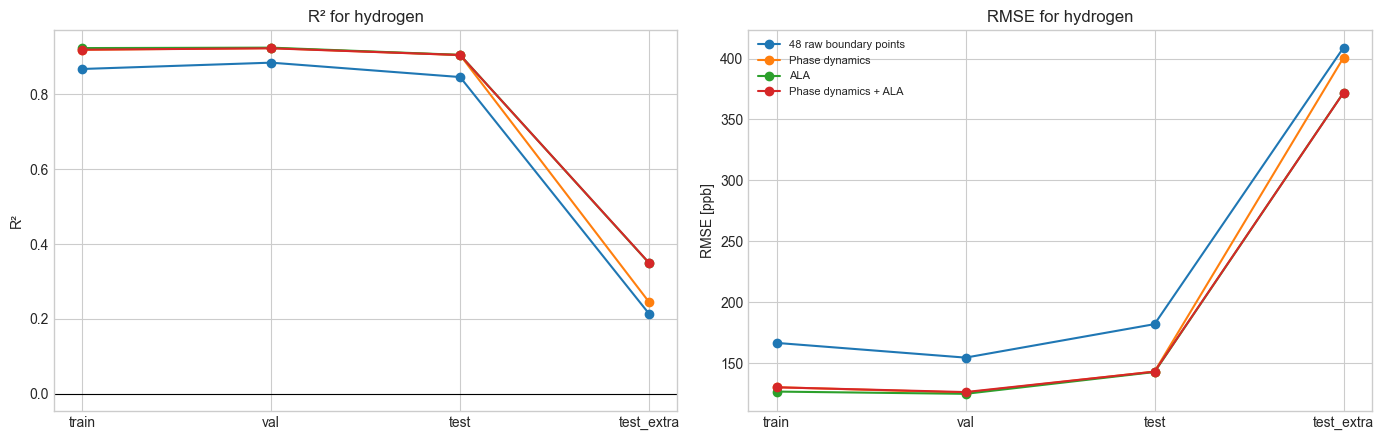

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))
for feature_name in feature_sets:
    subset = [row for row in rows if row["Features"] == feature_name]
    axes[0].plot([row["Split"] for row in subset],
                 [row["R2"] for row in subset], marker="o", label=feature_name)
    axes[1].plot([row["Split"] for row in subset],
                 [row["RMSE"] for row in subset], marker="o", label=feature_name)
axes[0].axhline(0, color="black", linewidth=0.8)
axes[0].set(title=f"R² for {GAS}", ylabel="R²")
axes[1].set(title=f"RMSE for {GAS}", ylabel="RMSE [ppb]")
axes[1].legend(fontsize=8)
plt.tight_layout()
plt.show()

## 4. Which physical features carry information?

In [11]:
y_train = splits["train"]["targets"][GAS].astype(float)
correlations = []
for index, name in enumerate(phase_names):
    x = phase_features["train"][:, index]
    if np.std(x) < 1e-12:
        continue
    correlation = np.corrcoef(x, y_train)[0, 1]
    if not np.isfinite(correlation):
        continue
    correlations.append({
        "Feature": name,
        "Training correlation": correlation,
        "|Correlation|": abs(correlation),
    })
correlation_table = sorted(
    correlations, key=lambda row: row["|Correlation|"], reverse=True
)[:20]
show_table(
    correlation_table,
    ["Feature", "Training correlation", "|Correlation|"],
)

Feature,Training correlation,|Correlation|
step10_low_t350__amplitude,-0.801,0.801
step11_low_t375__amplitude,-0.790,0.790
step11_high_t400__amplitude,0.787,0.787
step11_high_t400__initial_slope_per_s,0.786,0.786
step10_high_t400__initial_slope_per_s,0.759,0.759
step09_low_t325__amplitude,-0.755,0.755
step10_high_t400__amplitude,0.750,0.750
step00_high_t400__amplitude,0.750,0.750
step00_high_t400__initial_slope_per_s,0.732,0.732
step10_high_t400__tau63_s,-0.709,0.709


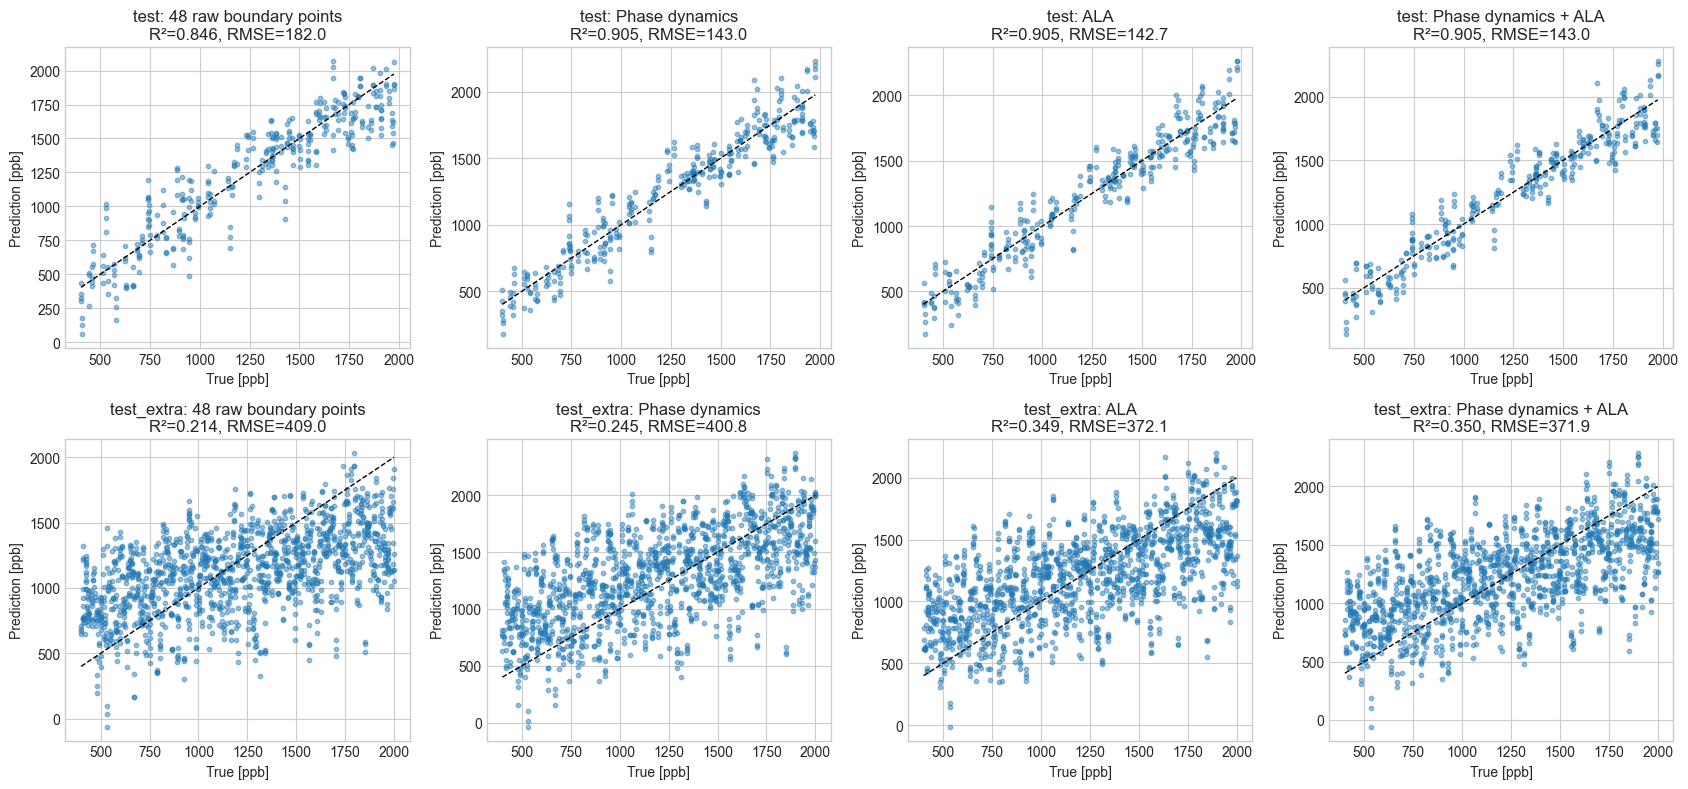

In [12]:
models_to_show = ["48 raw boundary points", "Phase dynamics", "ALA",
                  "Phase dynamics + ALA"]
evaluation_splits = ("test", "test_extra")
fig, axes = plt.subplots(2, 4, figsize=(17, 8))
for row, split in enumerate(evaluation_splits):
    y_true = splits[split]["targets"][GAS].astype(float)
    lower = float(y_true.min())
    upper = float(y_true.max())
    for column, name in enumerate(models_to_show):
        ax = axes[row, column]
        prediction = fitted[name][2][split]
        ax.scatter(y_true, prediction, s=10, alpha=0.45)
        ax.plot([lower, upper], [lower, upper], "k--", linewidth=1)
        score = regression_metrics(y_true, prediction)
        ax.set(
            xlabel="True [ppb]", ylabel="Prediction [ppb]",
            title=(
                f"{split}: {name}\n"
                f"R²={score['R2']:.3f}, RMSE={score['RMSE']:.1f}"
            ),
        )
plt.tight_layout()
plt.show()

## Interpretation

- tau63 is physically interpretable only when a phase approximately follows a first-order response.
- ALA is data-adaptive but not gas-specific; its boundaries follow training signal shape.
- Strong validation performance does not guarantee extrapolation to `test_extra`.
- ALA is used as feature extraction, not as a separate regression model.

Examples: [Baur et al., JSSS 2023](https://jsss.copernicus.org/articles/12/45/2023/)
and [Robin et al., Atmosphere 2023](https://www.mdpi.com/2073-4433/14/7/1123).